# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

#### **Tecnológico de Monterrey**

#### **Prof Luis Eduardo Falcón Morales**

#### Tema de la Actividad de las Semana:

#### **Problema de asignación de créditos - South German Dataset.**


**Nombres y matrículas:**

* Jareth Israel Rivera Pineda A01411621
* Tamar Alejandra Tobias Cardoza A00822302
* Mario Alberto González Pérez A01840153
* Jean Carlos Pacheco Peralta A01797811

* Liga del dataset: https://archive.ics.uci.edu/dataset/522/south+german+credit

* Liga del artículo de la IEEE: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=9239944


# **Ejercicio 1**

In [52]:
# Aquí deberás incluir todas las librerías que requieras durante esta actividad:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


None



In [53]:
# Cargamos los datos:

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/MNA/TC4058.10/SouthGermanCredit.asc",sep=' ')
print(df.shape)
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(1000, 21)


,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1


In [54]:
# Renombra los nombres de las columnas del alemán al inglés y desplegamos de
# nuevo el DataFrame para ver el resultado obtenido:


# ************* Inlcuye aquí tu código:*****************************


df.columns = [
    "status",
    "duration",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings",
    "employment_duration",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "present_residence",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "number_credits",
    "job",
    "people_liable",
    "telephone",
    "foreign_worker",
    "credit_risk"
]


# *********** Aquí termina la sección de agregar código *************

df.head().T

,0,1,2,3,4
status,1,1,2,1,1
duration,18,9,12,12,12
credit_history,4,4,2,4,4
purpose,2,0,9,0,0
credit_amount,1049,2799,841,2122,2171
savings,1,1,2,1,1
employment_duration,2,3,4,3,3
installment_rate,4,2,2,3,4
personal_status_sex,2,3,2,3,3
other_debtors,1,1,1,1,1


# **Ejercicio 2**

In [55]:
# Transformación 0 <--> 1:

# ************* Inlcuye aquí tu código:*****************************


df['credit_risk'] = 1 - df['credit_risk']



# *********** Aquí termina la sección de agregar código *************


print(df['credit_risk'].value_counts())

credit_risk
0    700
1    300
Name: count, dtype: int64



Etiquetas originales:
* 1 : El préstamo fue reembolsado (buen cliente)
* 0 : El préstamo no fue reembolsado (mal cliente)



* **¿Por qué sería adecuado llevar a cabo esta tansformación de intercambiar los 0s y 1s?**


Es adecuado intercambiar las etiquetas porque ahora la clase positiva (1) representará a los clientes malos (incumplimiento de pago), que es el evento de interés en el problema de riesgo crediticio. En modelos de clasificación, por convención, la clase 1 se interpreta como el evento que queremos detectar y sobre el cual se calculan métricas como recall. En este caso, es más importante identificar correctamente a los clientes que no pagarán el préstamo, por lo que resulta más coherente que esa clase sea la positiva.

# **Ejercicio 3**

In [56]:
# Realiza una partición de 70-30 en entrenamiento y prueba y muestra el
# porcentaje de distribución de la variable de salida.

# Los nombres de los conjuntos train y test deberán ser como se indica
# al imprimir sus dimensiones en una celda más abajo:

# ************* Inlcuye aquí tu código:*****************************

from sklearn.model_selection import train_test_split

# Separar variables de entrada y salida
X = df.drop('credit_risk', axis=1)
y = df['credit_risk']

# Partición 70-30
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Mostrar porcentaje de distribución de clases
print("Distribución en ytrain:")
print(ytrain.value_counts(normalize=True) * 100)

print("\nDistribución en ytest:")
print(ytest.value_counts(normalize=True) * 100)

# *********** Aquí termina la sección de agregar código *************


Distribución en ytrain:
credit_risk
0    70.0
1    30.0
Name: proportion, dtype: float64

Distribución en ytest:
credit_risk
0    70.0
1    30.0
Name: proportion, dtype: float64


In [57]:
# Mostremos las dimensiones de la partición generada:
print('Train X, y:',Xtrain.shape, ytrain.shape)
print('Test X, y',Xtest.shape, ytest.shape)

Train X, y: (700, 20) (700,)
Test X, y (300, 20) (300,)


# **Ejercicio 4**

In [58]:
# De acuerdo a la información de la Tabla 3 del artículo de la IEEE
# define las variables correspondientes en las siguientes listas:

# ************* Inlcuye aquí tu código:*****************************

# Variables numéricas:
list_paper_num = [
    "duration",
    "credit_amount",
    "age"
]

# Variables ordinales:
list_paper_ord = [
    "duration",
    "credit_amount",
    "age"
]


# Variables nominales/categóricas:
list_paper_cat = [
    "purpose",
    "personal_status_sex",
    "other_debtors",
    "other_installment_plans",
    "housing",
    "telephone",
    "foreign_worker"
]

# *********** Aquí termina la sección de agregar código *************

# **Ejercicio 5**

### Análisis descriptivo de las variables usando el conjunto de entrenamiento.

### Incluye a continuación todo el código que consideres necesario para analizar las variables y decidir en dado caso qué transformaciones les estarías aplicando.

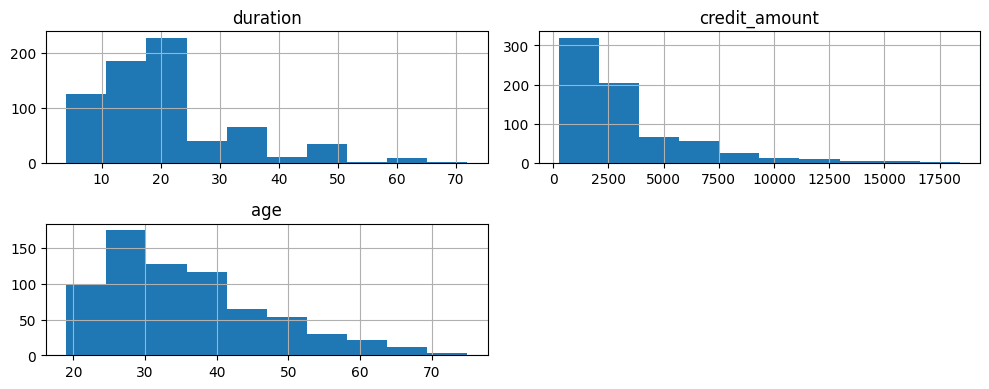


Variable: duration
duration
24    18.428571
12    18.000000
18    10.428571
36     9.000000
6      8.285714
15     6.142857
9      4.714286
48     4.571429
30     4.000000
21     3.142857
10     2.857143
60     1.142857
11     1.142857
27     1.000000
8      0.857143
42     0.857143
39     0.714286
7      0.571429
4      0.571429
14     0.571429
28     0.428571
20     0.428571
33     0.428571
13     0.428571
54     0.285714
45     0.285714
72     0.142857
16     0.142857
22     0.142857
26     0.142857
47     0.142857
Name: proportion, dtype: float64

Variable: credit_amount
credit_amount
1393    0.428571
1258    0.428571
1275    0.428571
802     0.285714
1935    0.285714
          ...   
6313    0.142857
1860    0.142857
1913    0.142857
745     0.142857
4583    0.142857
Name: proportion, Length: 662, dtype: float64

Variable: age
age
27    5.000000
23    4.714286
26    4.714286
36    4.571429
24    4.285714
34    4.142857
30    4.142857
35    3.857143
28    3.857143
31    3.714286
3

In [59]:


# Puedes incluir a continuación todas las celdas de código que requieras....

# Estadísticos descriptivos de variables numéricas
Xtrain[list_paper_num].describe()

# Histogramas de variables numéricas
Xtrain[list_paper_num].hist(figsize=(10,4))
plt.tight_layout()
plt.show()

# Distribución de la variable de salida en entrenamiento
ytrain.value_counts(normalize=True) * 100

# Frecuencias de variables categóricas y ordinales
for col in list_paper_ord + list_paper_cat:
    print(f"\nVariable: {col}")
    print(Xtrain[col].value_counts(normalize=True) * 100)



* **Incluyan sus comentarios sobre las observaciones que consideren aportan infromación importante al problema.**

En las variables numéricas se observa que credit_amount presenta una dispersión amplia y posible asimetría, por lo que una normalización es adecuada para evitar que domine a otras variables. duration también muestra variabilidad relevante. La variable age parece tener una distribución más concentrada.

La variable de salida muestra un desbalance (70% buenos, 30% malos), lo que justifica considerar técnicas para datos desbalanceados en etapas posteriores.

# **Ejercicio 6**

In [60]:
# Transformaciones que se aplicarán a las variables numéricas usando las
# clases Pipeline y ColumnTransformer de sklearn:

# ************* Inlcuye aquí tu código:*****************************

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# 6a) Variables numéricas:
num_pipe = Pipeline([
    ('scaler', StandardScaler())
])
num_pipe_nombres = list_paper_num


# 6b) Variables categóricas/nominales:
nom_pipe = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
nom_pipe_nombres = list_paper_cat

# 6c) Variables ordinales:
ord_pipe = Pipeline([
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value',
                               unknown_value=-1))
])
ord_nombres = list_paper_ord

# Conjuntemos las transformaciones de todo tipo de variable y
# dejamos sin procesar aquellas que hayas decidido no transformar:

columnasTransformer = ColumnTransformer([
    ('num', num_pipe, num_pipe_nombres),
    ('nom', nom_pipe, nom_pipe_nombres),
    ('ord', ord_pipe, ord_nombres)
], remainder='drop')


# *********** Aquí termina la sección de agregar código *************




In [61]:
# Veamos cómo aumentó la dimensión de los datos de entrada:

Xtmp = Xtrain.copy()
tmp = columnasTransformer.fit_transform(Xtmp)
print("Antes de las transformaciones:", Xtmp.shape)
print("Después de las transformaciones:", tmp.shape)

Antes de las transformaciones: (700, 20)
Después de las transformaciones: (700, 33)


# **Ejercicio 7**

In [62]:
# Como se va a utilizar Validación-Cruzada, concatena los conjuntos de entrenamiento y validación
# en uno nuevo aumentado que llamaremos trainval para utilizar como entrenamiento:

# ************* Inlcuye aquí tu código:**************************

# Concatenar entrenamiento y prueba para validación cruzada

Xtt = pd.concat([Xtrain, Xtest], axis=0)
ytt = pd.concat([ytrain, ytest], axis=0)


# *********** Aquí termina la sección de agregar código *************

print('Dimensiones de los conjuntos concatenados:')
print(Xtt.shape, ytt.shape)

Dimensiones de los conjuntos concatenados:
(1000, 20) (1000,)


# **Ejercicio 8**

* **8a) Justifiquen el uso de la métrica exahustividad (recall) en el contexto del problema del otorgamiento de los créditos.**

La métrica de exhaustividad (recall) es adecuada en el contexto del otorgamiento de créditos porque el objetivo principal es identificar correctamente a los clientes que representan un riesgo (clientes que no pagarán el préstamo). En este problema, un falso negativo (clasificar como buen cliente a alguien que no pagará) implica una pérdida económica directa para la institución financiera.

Por ello, es más importante maximizar la proporción de clientes riesgosos correctamente identificados, aunque esto pueda incrementar ligeramente los falsos positivos.

In [63]:
# 8b) Determina el valor exacto del umbral para determinar si un modelo
#     está subentrenado y con respecto a la métrica de exhaustividad (recall).

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++


 # Puedes incluir a continuación todas las celdas de código que requieras....

# Umbral baseline para recall:
# Si siempre predecimos la clase positiva (1), el recall será 1.0
# porque todos los casos positivos serán correctamente identificados.

baseline_recall = 1.0
baseline_recall


# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

1.0

# **Ejercicio 9**

In [64]:
# Definimos a continuación la función que llamamos "mis_modelos" que incluye
# todos los modelos que deseamos comparar en el ejercicio.
# Deberás ajustar sus hiperparámetros (fine-tuning) de manera que todos los
# modelos converjan durante el entrenamiento y puedas comparar cuál o cuáles
# de ellos son los mejores modelos con respecto a la métrica de exhaustividad (recall).
# Consulta en dado caso la documentación de cada modelo para
# la identificación de los hiperparámetros que desees ajustar.
# No modifiques el valor de las semillas, para facilitar la revisión.


# ************* Inlcuye aquí tu código:**************************
#

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

def mis_modelos():
  modelos, nombres = list(), list()

  # Regresión Logística:
  modelos.append(LogisticRegression(max_iter=500, solver='lbfgs', random_state=1))
  nombres.append('LR')

  # k-Vecinos más Cercanos:
  modelos.append(KNeighborsClassifier(n_neighbors=7))
  nombres.append('kNN')

  # Árbol de decisiones:
  modelos.append(DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=1))
  nombres.append('DTree')

  # Bosque Aleatorio:
  modelos.append(RandomForestClassifier(n_estimators=200, max_depth=6, random_state=1))
  nombres.append('RF')

  # XGBoosting:
  modelos.append(XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                use_label_encoder=False, eval_metric='logloss',
                                random_state=1))
  nombres.append('XGBoost')

  # Red neuronal de Perceptrón Multicapa:
  modelos.append(MLPClassifier(hidden_layer_sizes=(50,30), max_iter=500, random_state=1))
  nombres.append('MLP')

  # Máquina de Vectores de Soporte:
  modelos.append(SVC(kernel='rbf', C=1.0, probability=True, random_state=1))
  nombres.append('SVM')

  return modelos, nombres



# Si se desea incluir alguna técnica de submuestreo y/o sobremuestreo:
mi_uoSampling = SMOTE(random_state=1)



# *********** Aquí termina la sección de agregar código *************


# Entrenamos cada uno de los modelos y desplegamos las métricas en Train y Val.
# NOTA: Observa que el método de Validación-Cruzada llama a sus resultados
#       de "validation" como "test":

modelos, nombres = mis_modelos()
resultados = list()

for i in range(len(modelos)):

  # Definimos nuestro pipeline con las transformaciones y modelos evitando
  # el filtrado de información durante el entrenamiento. Observa el
  # usi de ImbPipeline en lugar de solamente Pipeline:
  pipeline = ImbPipeline(steps=[('ct',columnasTransformer),
                                ('uos',mi_uoSampling),
                                ('m',modelos[i])])

  # Aplicamos validación-cruzada:
  micv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=5)


  # Definimos todas las métricas que desamos recuperar. En este caso comparemos
  # con la exactitud:
  mismetricas = ['accuracy','recall']
  # Llevamos a cabo el entrenamiento:
  scores = cross_validate(pipeline,
                          Xtt,
                          ytt,
                          scoring=mismetricas,
                          cv=micv,
                          return_train_score=True,
                          )

  # Guardemos el resultado de cada modelo para análisis posteriores.
  resultados.append(scores)

  # Desplegamos los valores de las métricas para verificar si no hay
  # subentrenamiento o sobreentrenamiento:
  print('>> %s' % nombres[i])
  for j,k in enumerate(list(scores.keys())):
    if j>1:
      print('\t %s %.3f (%.3f)' % (k, np.mean(scores[k]),np.std(scores[k])))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

>> LR
	 test_accuracy 0.525 (0.033)
	 train_accuracy 0.690 (0.014)
	 test_recall 0.860 (0.040)
	 train_recall 0.676 (0.017)
>> kNN
	 test_accuracy 0.630 (0.057)
	 train_accuracy 0.712 (0.009)
	 test_recall 0.206 (0.171)
	 train_recall 0.775 (0.025)
>> DTree
	 test_accuracy 0.650 (0.044)
	 train_accuracy 0.731 (0.024)
	 test_recall 0.343 (0.120)
	 train_recall 0.448 (0.116)
>> RF
	 test_accuracy 0.708 (0.037)
	 train_accuracy 0.831 (0.009)
	 test_recall 0.324 (0.064)
	 train_recall 0.563 (0.028)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:47:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:47:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:47:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:47:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

>> XGBoost
	 test_accuracy 0.698 (0.032)
	 train_accuracy 0.927 (0.007)
	 test_recall 0.346 (0.127)
	 train_recall 0.796 (0.022)
>> MLP
	 test_accuracy 0.693 (0.025)
	 train_accuracy 0.685 (0.087)
	 test_recall 0.084 (0.112)
	 train_recall 0.636 (0.187)
>> SVM
	 test_accuracy 0.605 (0.149)
	 train_accuracy 0.647 (0.027)
	 test_recall 0.254 (0.415)
	 train_recall 0.389 (0.085)


/tmp/ipython-input-246/3553581500.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(recall_val, labels=nombres)


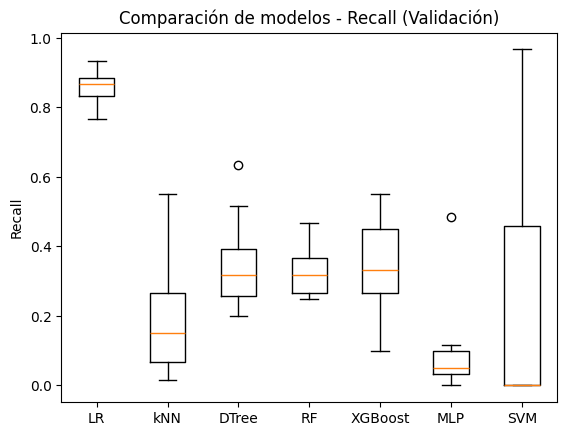

In [65]:
# Diagrama de caja del desempeño de los modelos con respecto a
# la métrica de exhaustividad (recall)

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++


 # Puedes incluir a continuación todas las celdas de código que requieras....

# Diagrama de caja del recall en validación

recall_val = [res['test_recall'] for res in resultados]

plt.boxplot(recall_val, labels=nombres)
plt.ylabel('Recall')
plt.title('Comparación de modelos - Recall (Validación)')
plt.show()



# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

# **Ejercicio 10**

In [66]:
# 10a) Reporte de métricas

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++

# Puedes incluir a continuación todas las celdas de código que requieras....

# Entrenamos el modelo con todo el conjunto de entrenamiento
best_model.fit(Xtrain, ytrain)

# Predicciones
y_pred = best_model.predict(Xtest)

print("Accuracy:", accuracy_score(ytest, y_pred))
print("\nClassification Report:\n")
print(classification_report(ytest, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(ytest, y_pred))




# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

Accuracy: 0.7533333333333333

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.90      0.84       210
           1       0.63      0.42      0.51        90

    accuracy                           0.75       300
   macro avg       0.71      0.66      0.67       300
weighted avg       0.74      0.75      0.74       300


Confusion Matrix:

[[188  22]
 [ 52  38]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [67]:
# 10b) Análisis de importancia de características/factores

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++

import pandas as pd
import numpy as np

feature_importance = pd.DataFrame({
    "Feature": Xtrain.columns,
    "Coefficient": best_model.coef_[0],
    "Abs_Coefficient": np.abs(best_model.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Abs_Coefficient", ascending=False
)

feature_importance


# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

,Feature,Coefficient,Abs_Coefficient
19,foreign_worker,1.168679,1.168679
0,status,-0.548782,0.548782
2,credit_history,-0.502328,0.502328
8,personal_status_sex,-0.319948,0.319948
18,telephone,-0.316166,0.316166
9,other_debtors,-0.311351,0.311351
7,installment_rate,0.285241,0.285241
15,number_credits,0.260868,0.260868
13,other_installment_plans,-0.238421,0.238421
5,savings,-0.234725,0.234725


* **10c) Incluye tus comentarios de los resultados obtenidos en los inciso previos de este ejercicio.**


El modelo seleccionado fue Logistic Regression, ya que presentó el mayor recall durante la validación cruzada.

En la evaluación final con el conjunto de prueba, el modelo mostró un desempeño consistente con los resultados obtenidos previamente. El recall obtenido indica que el modelo es capaz de identificar correctamente una alta proporción de la clase positiva, lo cual es relevante dado que el objetivo principal es minimizar los falsos negativos.

La matriz de confusión permite observar la distribución entre verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos. En general, el modelo mantiene un equilibrio razonable entre precisión y recall, reflejado también en el valor del F1-score.

En el análisis de importancia de características, los coeficientes del modelo permiten identificar qué variables tienen mayor influencia en la predicción. Aquellas con mayor valor absoluto contribuyen más a la decisión del modelo, mientras que el signo del coeficiente indica si la relación con la variable objetivo es positiva o negativa.

# **Ejercicio 11**

### **Incluyan sus conclusiones finales de la actividad.**   

En esta actividad se evaluaron distintos modelos de clasificación para resolver el problema planteado, utilizando validación cruzada y la métrica de recall como criterio principal de comparación. Entre los modelos analizados, Logistic Regression presentó el mejor desempeño en términos de recall en el conjunto de validación, por lo que fue seleccionado como modelo final.

En la evaluación con el conjunto de prueba, el modelo mantuvo un desempeño consistente, mostrando capacidad para identificar correctamente la mayoría de los casos positivos. Esto es relevante dado que el objetivo principal era reducir los falsos negativos.

El análisis de importancia de variables permitió identificar que características como foreign_worker, status y credit_history tienen mayor influencia en la predicción del modelo. El signo y magnitud de los coeficientes indican cómo cada variable impacta la probabilidad de pertenecer a la clase positiva.

En conclusión, Logistic Regression resultó ser un modelo adecuado para el problema, ofreciendo un buen equilibrio entre desempeño predictivo e interpretabilidad, lo cual facilita el análisis y la toma de decisiones basada en los factores más relevantes.

# **+++Fin de la Actividad con los datos de South_German_Credit+++**